In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.optim import Optimizer
import torchmetrics

device = "cuda"

In [17]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55000, 5000])

In [18]:
from torch.utils.data import DataLoader

batch_size = 512
num_workers = 4
persistent_workers = True
pin_memory = True

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=num_workers, persistent_workers=persistent_workers)
valid_loader = DataLoader(valid_data, batch_size=batch_size, pin_memory=pin_memory, num_workers=num_workers, persistent_workers=persistent_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, pin_memory=pin_memory, num_workers=num_workers, persistent_workers=persistent_workers)

Label	Class
0	T-shirt/top
1	Trouser
2	Pullover
3	Dress
4	Coat
5	Sandal
6	Shirt
7	Sneaker
8	Bag
9	Ankle boot

In [19]:
X_sample, y_sample = train_data[0]
X_sample.shape

torch.Size([1, 28, 28])

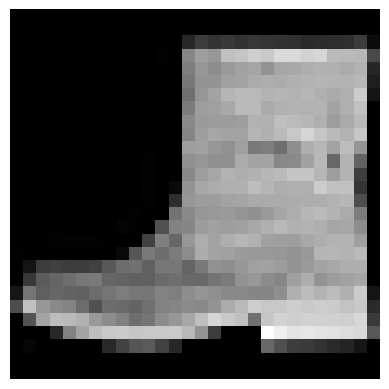

'Ankle boot'

In [20]:
plt.imshow(X_sample.squeeze(), cmap="gray")
plt.axis("off")
plt.show()
train_and_valid_data.classes[y_sample]

In [21]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )
        
    def forward(self, X):
        return self.mlp(X)

In [22]:
def train(model:nn.Module, criterion, optimizer:Optimizer, n_epochs:int, datalodaer:DataLoader):
    model.to(device)
    model.train()
    for i in range(n_epochs):
        total_loss = 0
        for X, y in datalodaer:
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = criterion(y_pred, y)
            loss.backward()
            total_loss += loss
            optimizer.step()

        mean_loss = total_loss/len(datalodaer)
        print(f"epoch:{i}, total_loss:{mean_loss}")

def eval(model:nn.Module, dataloader:DataLoader, metric_fn, aggregate_fn = torch.mean):
    model.to(device)
    model.eval()
    metrics = []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            metric = metric_fn(y_pred, y)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [23]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10)
xentropy = nn.CrossEntropyLoss()
lr = 0.001
n_epochs = 10
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr)

In [24]:
train(model, xentropy, optimizer, n_epochs, train_loader)

epoch:0, total_loss:0.8004028797149658
epoch:1, total_loss:0.46115851402282715
epoch:2, total_loss:0.40378281474113464
epoch:3, total_loss:0.3715795874595642
epoch:4, total_loss:0.34777605533599854
epoch:5, total_loss:0.3298772871494293
epoch:6, total_loss:0.3152447044849396
epoch:7, total_loss:0.3022856116294861
epoch:8, total_loss:0.29430827498435974
epoch:9, total_loss:0.2813374996185303


In [25]:
print(eval(model, train_loader, accuracy))
print(eval(model, valid_loader, accuracy))

tensor(0.8932, device='cuda:0')
tensor(0.8663, device='cuda:0')


In [26]:
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)

y_pred = y_pred_logits.argmax(dim=1)
y_pred


tensor([7, 4, 2], device='cuda:0')

In [27]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.9460, 0.0010,
         0.0520],
        [0.0000, 0.0000, 0.0180, 0.0000, 0.9730, 0.0000, 0.0090, 0.0000, 0.0000,
         0.0000],
        [0.0020, 0.0000, 0.8800, 0.0010, 0.0240, 0.0000, 0.0930, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

In [28]:
y_top4_logits, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_logits, dim=1)
y_top4_probas.round(decimals=3)

tensor([[0.9460, 0.0520, 0.0010, 0.0010],
        [0.9730, 0.0180, 0.0090, 0.0000],
        [0.8810, 0.0930, 0.0240, 0.0020]], device='cuda:0')

In [ ]:
import optuna

def objective(trial:optuna.Trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    train(model, criterion, optimizer, 1, train_loader)
    validation_accuracy = eval(model, valid_loader, accuracy)
    return validation_accuracy

In [30]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-05-23 15:03:56,011] A new study created in memory with name: no-name-72772448-56d1-43d6-858b-9ccde0803df3


epoch:0, total_loss:2.3066654205322266
epoch:1, total_loss:2.3025660514831543
epoch:2, total_loss:2.298560380935669
epoch:3, total_loss:2.2944746017456055
epoch:4, total_loss:2.2904953956604004
epoch:5, total_loss:2.286489963531494
epoch:6, total_loss:2.282531261444092
epoch:7, total_loss:2.2785542011260986
epoch:8, total_loss:2.2746424674987793
epoch:9, total_loss:2.270700454711914


[I 2026-05-23 15:04:15,935] Trial 0 finished with value: 0.1519331932067871 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.1519331932067871.


epoch:0, total_loss:2.2542972564697266
epoch:1, total_loss:2.1081058979034424
epoch:2, total_loss:1.8442580699920654
epoch:3, total_loss:1.525861144065857
epoch:4, total_loss:1.2818630933761597
epoch:5, total_loss:1.1205552816390991
epoch:6, total_loss:1.011102318763733
epoch:7, total_loss:0.9353607892990112
epoch:8, total_loss:0.8803768157958984
epoch:9, total_loss:0.838182270526886


[I 2026-05-23 15:04:35,218] Trial 1 finished with value: 0.6926140189170837 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.6926140189170837.


...

[I 2026-05-23 15:04:54,520] Trial 2 finished with value: 0.0957987904548645 and parameters: {'learning_rate': 4.207988669606632e-05, 'n_hidden': 63}. Best is trial 1 with value: 0.6926140189170837.


epoch:0, total_loss:2.3039591312408447
epoch:1, total_loss:2.3037662506103516
epoch:2, total_loss:2.30359148979187
epoch:3, total_loss:2.303395986557007
epoch:4, total_loss:2.303138256072998
epoch:5, total_loss:2.302974224090576
epoch:6, total_loss:2.3028039932250977
epoch:7, total_loss:2.302570104598999
epoch:8, total_loss:2.3023841381073
epoch:9, total_loss:2.302201509475708


[I 2026-05-23 15:05:13,641] Trial 3 finished with value: 0.08779098093509674 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.6926140189170837.


epoch:0, total_loss:2.2937703132629395
epoch:1, total_loss:2.266536235809326
epoch:2, total_loss:2.23659610748291
epoch:3, total_loss:2.2008211612701416
epoch:4, total_loss:2.156586170196533
epoch:5, total_loss:2.101959705352783
epoch:6, total_loss:2.0347025394439697
epoch:7, total_loss:1.9541677236557007
epoch:8, total_loss:1.8604907989501953
epoch:9, total_loss:1.7573587894439697


[I 2026-05-23 15:05:33,011] Trial 4 finished with value: 0.49984055757522583 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.6926140189170837.


In [31]:
print(study.best_params)
print(study.best_value)

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}
0.6926140189170837


In [32]:
from functools import partial

objective_with_data = partial(objective, train_loader = train_loader, valid_loader=valid_loader)

In [35]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)


[I 2026-05-23 15:08:53,902] A new study created in memory with name: no-name-6965ea52-8db0-4e3d-8f24-1bb55d0ed83d


In [ ]:
#not best model
model.state_dict()

OrderedDict([('mlp.1.weight',
              tensor([[ 6.5116e-02,  5.6474e-02,  1.0162e-01,  ...,  7.8309e-02,
                        8.3681e-02,  1.0234e-01],
                      [-1.8812e-02, -4.0276e-02,  1.8694e-02,  ..., -1.7799e-02,
                       -6.0617e-03,  5.5503e-03],
                      [-7.8470e-04,  1.6534e-03, -1.1966e-04,  ..., -6.6807e-03,
                       -1.2854e-02,  5.8522e-03],
                      ...,
                      [-3.1972e-02, -1.1633e-01, -1.7650e-01,  ...,  2.7122e-02,
                        5.8982e-02,  9.4845e-02],
                      [-6.4441e-02,  6.8080e-02,  1.7118e-01,  ...,  8.5018e-02,
                        2.8831e-02,  1.3403e-01],
                      [-3.6845e-02,  1.2675e-02,  7.1846e-02,  ..., -7.0765e-02,
                       -1.0865e-01, -4.7522e-02]], device='cuda:0')),
             ('mlp.1.bias',
              tensor([ 1.7736e-01, -6.6525e-04,  1.7004e-02,  1.0803e-01,  6.4956e-02,
                      

In [ ]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {"n_inputs": 1 * 28 * 28, "n_hidden1": 300, "n_hidden2": 100}
}
torch.save(model_data, "my_fashion_mnist_model.pt")

SyntaxError: ':' expected after dictionary key (2220826171.py, line 3)

In [39]:
new_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
n_classes=10)
loaded_weights = torch.load("my_fasion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)